<a href="https://colab.research.google.com/github/Jeremy26/bird-eye-view/blob/claude%2Fbev-visualization-notebook-5mwjb/bev-visualization-notebook-5mwjb/bev-visualization-notebook-5mwjb/notebooks/bev_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bird Eye View Lab:** Lift, Splat, Shoot

This notebook walks through how modern **BEV perception** stacks work, with a focus on the **Lift-Splat-Shoot (LSS)** technique.

**What you will see:**
1. Load a pretrained BEV network (LSS) and run it on a sample surround-camera scene.
2. Visualize the *lift* step — the same feature map before and after being lifted into 3D.
3. Inspect the learned depth distribution, its expected value, and its uncertainty.
4. (Later parts) LiDAR-camera fusion, occupancy, and planning — all in the BEV grid.

> [Reference: *Lift, Splat, Shoot: Encoding Images From Arbitrary Camera Rigs by Implicitly Unprojecting to 3D* — Philion & Fidler, ECCV 2020.](https://arxiv.org/pdf/2008.05711)

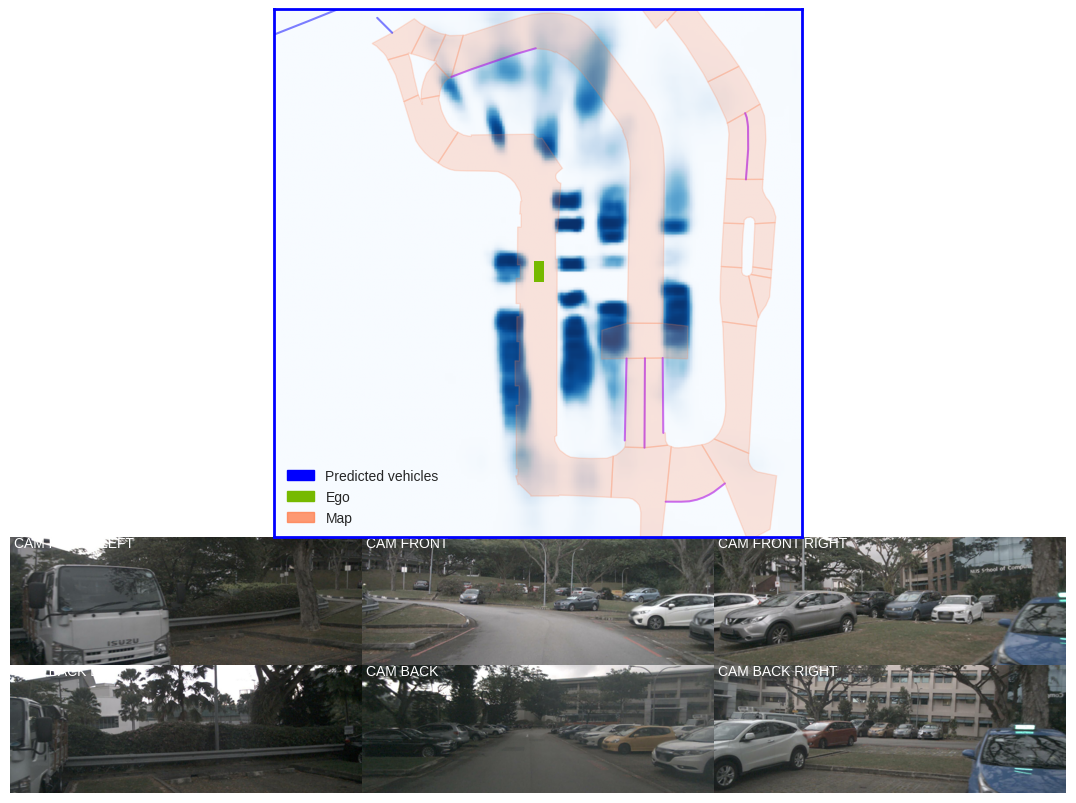

## Part 1 — Setup & load one real nuScenes sample

Four downloads: the LSS repo, the pretrained vehicle-segmentation weights, nuScenes mini, and the nuScenes map expansion.


In [2]:
!pip install -q pyquaternion nuscenes-devkit efficientnet_pytorch==0.7.1 gdown imageio-ffmpeg
!git clone -q https://github.com/nv-tlabs/lift-splat-shoot.git
!echo "" > lift-splat-shoot/src/__init__.py
!gdown -q https://drive.google.com/uc?id=18fy-6beTFTZx5SrYLs9Xk7cY-fGSm7kw #weights also available on https://drive.google.com/file/d/1bsUYveW_eOqa4lglryyGQNeC4fyQWvQQ/view - you can import them manually too
!mkdir -p nuscenes-mini && wget -q https://www.nuscenes.org/data/v1.0-mini.tgz -O- | tar -xz -C nuscenes-mini
!wget -qO mapexp.zip https://d36yt3mvayqw5m.cloudfront.net/public/v1.0/nuScenes-map-expansion-v1.3.zip
!unzip -qo mapexp.zip -d nuscenes-mini/maps

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.0/316.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
spopt 0.7.0 requires shapely

*You can disregard dependency warnings, for what we do, it won't matter much.*

-> Here, ***RESTART***

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, 'lift-splat-shoot')
import torch
import numpy as np
from PIL import Image
from nuscenes.nuscenes import NuScenes
from src.models import LiftSplatShoot
from src.data   import SegmentationData
from src.tools  import denormalize_img
from src.tools import plot_nusc_map, add_ego
import matplotlib.pyplot as plt, matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from nuscenes.map_expansion.map_api import NuScenesMap

# ── Colour palette (base: #202F46) ──
PAL = {
    'bg':     '#202F46',
    'surf':   '#1A2538',
    'grid':   '#2A3F5F',
    'text':   '#C9D6E8',
    'blue':   '#5B9BD5',
    'orange': '#F97316',
    'green':  '#4ADE80',
    'cyan':   '#22D3EE',
    'red':    '#F87171',
}

# Custom BEV colormap: bg -> blue -> orange (for vehicle probability)
BEV_CMAP = LinearSegmentedColormap.from_list('bev', [PAL['bg'], '#3A6BAD', PAL['blue'], PAL['orange']])

plt.style.use('dark_background')
mpl.rcParams.update({
    'figure.facecolor':  PAL['bg'],
    'axes.facecolor':    PAL['surf'],
    'savefig.facecolor': PAL['bg'],
    'text.color':        PAL['text'],
    'axes.labelcolor':   PAL['text'],
    'xtick.color':       PAL['text'],
    'ytick.color':       PAL['text'],
    'axes.edgecolor':    PAL['grid'],
    'grid.color':        PAL['grid'],
    'grid.alpha':        0.5,
    'axes.grid':         True,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
    'axes.prop_cycle':   mpl.cycler(color=[
        PAL['blue'], PAL['orange'], PAL['green'], PAL['cyan'], PAL['red'], '#A78BFA'
    ]),
})

From here, we are going to start working on the Bird Eye View. For this, we'll set:
* Grid Configurations & Cameras
* Get NuScenes Samples

In [2]:
grid_conf = {'xbound': [-50., 50., 0.5], 'ybound': [-50., 50., 0.5], #100x100 area around EGO, 0.5m per cell -> 200x200 total grid
             'zbound': [-10., 10., 20.], 'dbound': [4., 45., 1.]} #z is the height range, dbound are the depth bins, from 4m to 45m

data_aug_conf = {
    'resize_lim': (0.193, 0.225), 'final_dim': (128, 352),
    'rot_lim':    (-5.4, 5.4),    'H': 900, 'W': 1600,
    'rand_flip':  True,           'bot_pct_lim': (0., 0.22),
    'cams': ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
             'CAM_BACK_LEFT',  'CAM_BACK',  'CAM_BACK_RIGHT'],
    'Ncams': 6,
}
CAMS     = data_aug_conf['cams']
imH, imW = data_aug_conf['final_dim']

In [3]:
nusc = NuScenes('v1.0-mini', dataroot='nuscenes-mini', verbose=False)
ds   = SegmentationData(nusc, is_train=False, data_aug_conf=data_aug_conf, grid_conf=grid_conf)

LOCATIONS = ['singapore-hollandvillage', 'singapore-queenstown',
             'boston-seaport',           'singapore-onenorth']
nusc_maps = {loc: NuScenesMap(dataroot='nuscenes-mini', map_name=loc) for loc in LOCATIONS}
scene2map = {s['name']: nusc.get('log', s['log_token'])['location'] for s in nusc.scene}

NuscData: 81 samples. Split: val.
                   Augmentation Conf: {'resize_lim': (0.193, 0.225), 'final_dim': (128, 352), 'rot_lim': (-5.4, 5.4), 'H': 900, 'W': 1600, 'rand_flip': True, 'bot_pct_lim': (0.0, 0.22), 'cams': ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT'], 'Ncams': 6}


Then visualize the input data:

In [5]:
SAMPLE_IDX = 30
imgs, rots, trans, intrins, post_rots, post_trans, gt = ds[SAMPLE_IDX]

pil_images = [denormalize_img(imgs[i]) for i in range(6)]

print('loaded sample', SAMPLE_IDX, 'from scene',
      nusc.get('scene', ds.ixes[SAMPLE_IDX]['scene_token'])['name'])

plt.imshow(pil_images[0])

loaded sample 30 from scene scene-0916


### Load LSS Weights

In [12]:
# Choose Device, GPU or CPU
device   = 'cuda' if torch.cuda.is_available() else 'cpu'
# Get a Batch from the input
batch      = [x[None].to(device) for x in (imgs, rots, trans, intrins, post_rots, post_trans)]

# Load Model from the GitHub repo we downloaded
model = LiftSplatShoot(grid_conf, data_aug_conf, outC=1).to(device).eval()
model.load_state_dict(torch.load('model525000.pt', map_location=device))

# Run Inference
with torch.no_grad():
    bev = model(*batch).sigmoid()[0, 0].cpu().numpy()

Loaded pretrained weights for efficientnet-b0


### Visualize Output

In [18]:
# BEV cell size (cell_size) and the ego-frame coord of cell (0, 0) (grid_origin)
cell_size = np.array([grid_conf['xbound'][2], grid_conf['ybound'][2]])
grid_origin = np.array([grid_conf['xbound'][0] + cell_size[0]/2, grid_conf['ybound'][0] + cell_size[1]/2])

val = 0.01
fig = plt.figure(figsize=(3 * imW * val, (1.5 * imW + 2 * imH) * val))
gs  = mpl.gridspec.GridSpec(3, 3, height_ratios=(1.5 * imW, imH, imH))
gs.update(wspace=0, hspace=0, left=0, right=1, top=1, bottom=0)


<Figure size 1056x784 with 0 Axes>

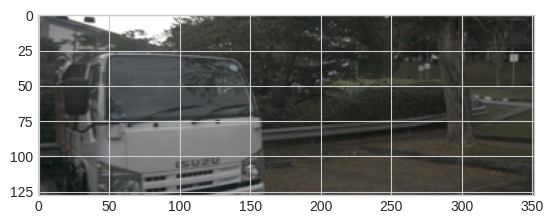

<Figure size 1056x784 with 0 Axes>

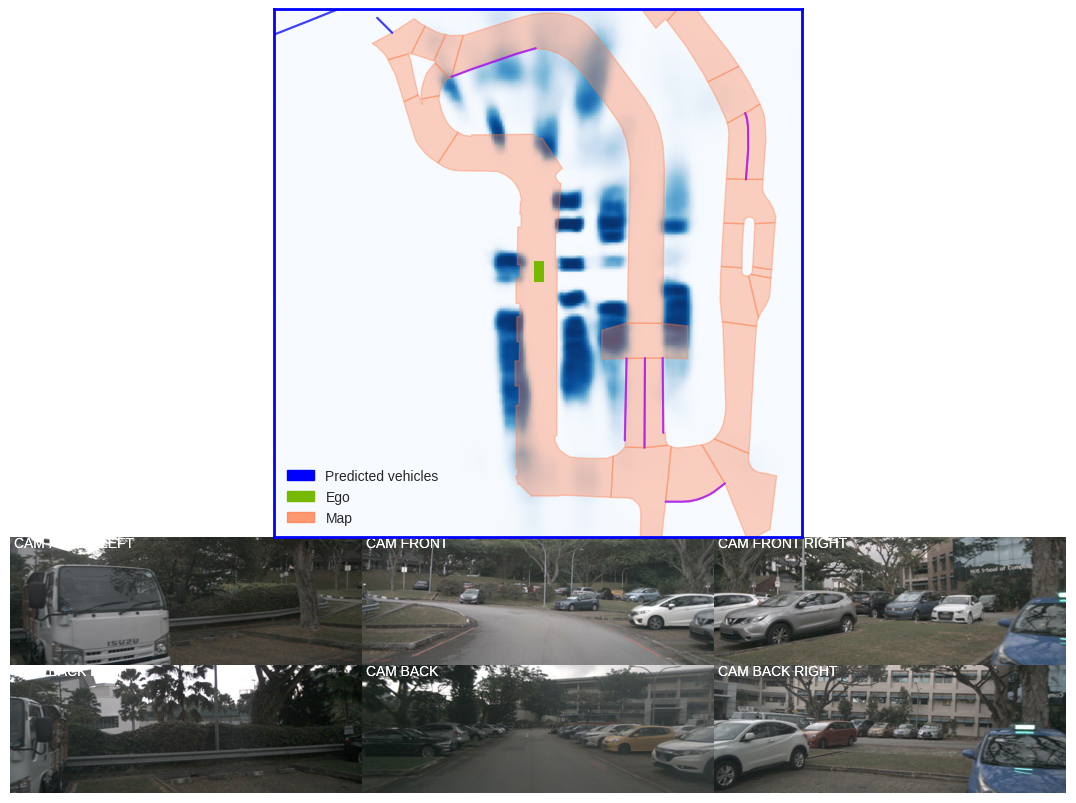

In [17]:
for i, cam in enumerate(CAMS):
    ax  = plt.subplot(gs[1 + i // 3, i % 3])
    img = pil_images[i].transpose(Image.FLIP_LEFT_RIGHT) if i > 2 else pil_images[i]
    plt.imshow(img); plt.axis('off')
    plt.annotate(cam.replace('_', ' '), (0.01, 0.92), xycoords='axes fraction', color='white')

ax = plt.subplot(gs[0, :])
plt.imshow(bev, vmin=0, vmax=1, cmap=BEV_CMAP)
plot_nusc_map(ds.ixes[SAMPLE_IDX], nusc_maps, nusc, scene2map, cell_size, grid_origin)
add_ego(grid_origin, cell_size)
plt.xlim(bev.shape[1], 0); plt.ylim(0, bev.shape[0])
plt.xticks([]); plt.yticks([])
plt.setp(ax.spines.values(), color='b', linewidth=2)
plt.legend(handles=[
    mpatches.Patch(color='blue',                label='Predicted vehicles'),
    mpatches.Patch(color='#76b900',             label='Ego'),
    mpatches.Patch(color=(1., 0.5, 0.31, 0.8),  label='Map'),
])
plt.show()

In [16]:
%matplotlib inline

## Part 2 — Visualizing the **Lift** step

### The problem: cameras don't know depth

A camera image is a 2D projection. Every pixel tells you the *direction* to look, but **not how far away the thing is**. A lane marking 5 m ahead and one 30 m ahead can sit on the exact same row of pixels.

To build a BEV grid you need to answer: *"for each pixel, which cell of the 100 m × 100 m box around the car does it belong to?"* — and that requires knowing depth.

### What Lift does — step by step

**Step 1 — extract a feature vector per pixel.**  
The EfficientNet-B0 backbone produces a 64-d descriptor `f(u, v)` for every (downsampled) pixel. Think of it as a compact answer to "what does this patch look like?" (colour, texture, edges).

**Step 2 — predict a depth probability distribution per pixel.**  
A lightweight prediction head outputs 41 numbers for each pixel — one per depth bin from 4 m to 45 m — and passes them through a softmax. The result `α(u, v, ·)` is a proper probability distribution: *"if something is at pixel (u,v), how likely is it that it's 4 m away? 5 m? … 45 m?"*

**Step 3 — outer product → 3D frustum.**  
Instead of committing to one depth (fragile), LSS places the feature at **all 41 depths simultaneously**, scaled by how likely each depth is:

```
lifted(u, v, d)  =  α(u, v, d)  ×  f(u, v)       shape: (41, 64) per pixel
```

The result is a **3D frustum** — a wedge of voxels filling the camera's field of view. Each voxel carries the same 64-d descriptor, but its magnitude is proportional to how much the network believes something sits at that depth.

### The "glowing streak" analogy

Imagine shining a laser from the camera through a pixel. Instead of a single bright dot at one distance, you get a **glowing streak along the ray** — brightest where the depth PDF peaks, faint everywhere else. That's exactly what the outer product does.

If the network is confident (sharp PDF), most of the feature "energy" lands in one thin slice of the BEV. If it's uncertain (flat PDF), the energy spreads across many bins — which is honest, not catastrophic.

The six cameras produce six frustums; the next step (**Splat**) piles all of them onto one shared BEV grid.

In [ ]:
# Unpack batch and flatten the 6 cameras into independent images for CamEncode
images_batch, rots_batch, trans_batch, intrins_batch, post_rots_batch, post_trans_batch = batch
B, N, _, imH, imW = images_batch.shape
images_flat = images_batch.view(B * N, 3, imH, imW)

with torch.no_grad():
    backbone_features = model.camencode.get_eff_depth(images_flat)         # (6, 512, feat_h, feat_w)
    depth_logits      = model.camencode.depthnet(backbone_features)         # (6, D+C, feat_h, feat_w)
    num_depth_bins    = model.camencode.D   # 41 bins, 4 m -> 45 m
    num_channels      = model.camencode.C   # 64 context features per pixel
    depth_dist        = depth_logits[:, :num_depth_bins].softmax(dim=1)     # (6, D, feat_h, feat_w)
    features_2d       = depth_logits[:, num_depth_bins:]                    # (6, C, feat_h, feat_w)
    lifted            = depth_dist.unsqueeze(1) * features_2d.unsqueeze(2)  # (6, C, D, feat_h, feat_w)
    geom              = model.get_geometry(rots_batch, trans_batch, intrins_batch,
                                           post_rots_batch, post_trans_batch)

feat_h, feat_w     = backbone_features.shape[-2:]
depth_bins_np      = torch.arange(*grid_conf["dbound"], dtype=torch.float32).numpy()
stride_y, stride_x = imH // feat_h, imW // feat_w

print(f'Feature grid : {feat_h} x {feat_w}   (stride {imH//feat_h} px per cell)')
print(f'Depth bins   : D={num_depth_bins}  ({depth_bins_np[0]:.0f} m -> {depth_bins_np[-1]:.0f} m)')
print(f'Context feats: C={num_channels}')
print()
print(f'depth_dist   {tuple(depth_dist.shape)}   <- alpha(u,v,d)')
print(f'features_2d  {tuple(features_2d.shape)}   <- f(u,v)')
print(f'lifted       {tuple(lifted.shape)}   <- alpha x f')

### 2.1 — The Lift: interactive explorer

Pick a camera and a feature-grid pixel. Three panels update live:

- **Left** — 2D feature map (PCA → RGB) overlaid on the image. Red box = selected patch.
- **Center** — depth probability distribution for that patch. Green line = expected depth.
- **Right** — the full 3D frustum for that camera (same PCA colours, opacity = α). The selected ray is drawn brighter.

In [ ]:
from sklearn.decomposition import PCA
from PIL import Image as PILImage
from ipywidgets import interact, IntSlider, Dropdown

def lift_explorer(camera='CAM_FRONT', fh=feat_h//2, fw=feat_w//2):
    cam_idx = CAMS.index(camera)

    C, H, W = features_2d[cam_idx].shape
    feat_np = features_2d[cam_idx].reshape(C, -1).T.cpu().numpy()
    pca     = PCA(n_components=3).fit_transform(feat_np)
    pca     = (pca - pca.min(0)) / (pca.max(0) - pca.min(0) + 1e-6)
    rgb_2d  = pca.reshape(H, W, 3)
    rgb_up  = np.asarray(PILImage.fromarray((rgb_2d * 255).astype(np.uint8))
                         .resize((imW, imH), PILImage.BICUBIC)) / 255.0

    u_px = fw * stride_x + stride_x // 2
    v_px = fh * stride_y + stride_y // 2
    pdf  = depth_dist[cam_idx, :, fh, fw].cpu().numpy()
    expected = float((pdf * depth_bins_np).sum())

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 5))

    ax0.imshow(pil_images[cam_idx])
    ax0.imshow(rgb_up, alpha=0.25)
                                linewidth=2.5, edgecolor=PAL['orange'], facecolor='none'))
    ax0.scatter([u_px], [v_px], c=PAL['orange'], s=100, edgecolor='white', linewidths=2, zorder=5)
    ax0.set_title(f'{camera} — 2D features (PCA→RGB)  |  orange box = selected patch', fontsize=10)
    ax0.axis('off')

    ax1.bar(depth_bins_np, pdf, width=0.9, color=PAL['blue'], alpha=0.9)
    ax1.fill_between(depth_bins_np, pdf, alpha=0.2, color=PAL['blue'])
    ax1.axvline(expected, color=PAL['green'], lw=2.5, linestyle='--', label=f'E[d] = {expected:.1f} m')
    ax1.set_xlabel('depth [m]'); ax1.set_ylabel('P(depth)')
    ax1.set_title(f'Depth PDF  —  peak at {depth_bins_np[pdf.argmax()]:.0f} m', fontsize=10)
    ax1.set_xlim(3.5, 45.5)
    ax1.legend(fontsize=9)

    plt.suptitle('Lift — 2D features + depth distribution at selected pixel', fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()

interact(
    lift_explorer,
    camera=Dropdown(options=CAMS, value='CAM_FRONT', description='camera'),
    fh=IntSlider(min=0, max=feat_h-1, step=1, value=feat_h//2, description='row'),
    fw=IntSlider(min=0, max=feat_w-1, step=1, value=feat_w//2, description='col'),
);

### 2.2 — 3D frustum (interactive, drag to rotate)

The same frustum as above but rendered with Plotly — fully rotatable in your browser.
Each dot is one voxel; its colour comes from the 2D PCA feature map and its opacity from α (the depth probability).

In [ ]:
import plotly.graph_objects as go

def show_frustum_3d(camera='CAM_FRONT'):
    cam_idx = CAMS.index(camera)

    C, H, W = features_2d[cam_idx].shape
    feat_np = features_2d[cam_idx].reshape(C, -1).T.cpu().numpy()
    pca     = PCA(n_components=3).fit_transform(feat_np)
    pca     = (pca - pca.min(0)) / (pca.max(0) - pca.min(0) + 1e-6)
    rgb_2d  = pca.reshape(H, W, 3)

    geom_cam  = geom[0, cam_idx].cpu().numpy()
    depth_cam = depth_dist[cam_idx].cpu().numpy()
    rgb_3d    = np.broadcast_to(rgb_2d[None], depth_cam.shape + (3,)).reshape(-1, 3)
    alphas    = depth_cam.reshape(-1)
    points    = geom_cam.reshape(-1, 3)
    keep      = alphas > 0.015

    clipped = np.clip(alphas[keep] * 5, 0.05, 0.85)
    colors  = [f'rgba({int(r*255)},{int(g*255)},{int(b*255)},{a:.2f})'
               for r, g, b, a in zip(rgb_3d[keep, 0], rgb_3d[keep, 1], rgb_3d[keep, 2], clipped)]

    fig = go.Figure(data=[
        go.Scatter3d(x=points[keep, 0], y=points[keep, 1], z=points[keep, 2],
                     mode='markers', marker=dict(size=2, color=colors), name='frustum'),
        go.Scatter3d(x=[0], y=[0], z=[0],
                     mode='markers', marker=dict(size=10, color='cyan', symbol='diamond'), name='ego'),
    ])
    fig.update_layout(
        template='plotly_dark',
        scene=dict(xaxis_title='x [m]', yaxis_title='y [m]', zaxis_title='z [m]',
                   bgcolor='#1A2538'),
        title=f'3D frustum — {camera}   (drag to rotate, scroll to zoom)',
        height=620, margin=dict(l=0, r=0, b=0, t=45),
    )
    fig.show()

interact(show_frustum_3d, camera=Dropdown(options=CAMS, value='CAM_FRONT', description='camera'));

### 2.3 — The **splat** — pooling all 6 cameras into one BEV grid

The final step is *splat*: every lifted voxel is scattered into its corresponding cell of a 2D BEV grid. Voxels that fall into the same cell are summed (the "cumulative-sum trick" in the LSS paper). This gives a single feature tensor `(C, 200, 200)` covering a 100 m × 100 m region around the ego vehicle.

We show two views of that tensor:
1. the L2 magnitude of the per-cell feature vector (where does LSS place *any* feature),
2. a PCA → RGB projection (what kind of features were placed where).

In [ ]:
with torch.no_grad():
    cam_features = model.get_cam_feats(images_batch)
    bev_feat     = model.voxel_pooling(geom, cam_features)

bev_magnitude = bev_feat[0].norm(dim=0).cpu().numpy()

print(f'cam_features : {tuple(cam_features.shape)}   ({6 * num_depth_bins * feat_h * feat_w:,} voxels scattered)')
print(f'bev_feat     : {tuple(bev_feat.shape)}')
print(f'active cells : {(bev_magnitude > 0).sum():,} / {200*200:,}')

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(bev_magnitude, cmap='magma')
add_ego(grid_origin, cell_size)
ax.set_xlim(bev_magnitude.shape[1], 0); ax.set_ylim(0, bev_magnitude.shape[0])
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('BEV feature magnitude after splat\n(brighter = more feature energy)')
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()

**Recap of Part 2.** We walked through every stage of a Lift-Splat-Shoot forward pass:

| Stage | Tensor shape | What it means |
|------|--------------|---------------|
| 2D image features | `(N, C, fH, fW)` | per-pixel context descriptor |
| Depth distribution | `(N, D, fH, fW)` | `p(depth)` per pixel |
| Lifted 3D frustum | `(N, C, D, fH, fW)` | outer product `α ⊗ f` |
| Voxel-pooled BEV | `(1, C, 200, 200)` | everything summed into one BEV grid |

Up next — **Part 3**: using these same building blocks to look at depth *uncertainty* across the scene and compare it against ground truth when available. Then Parts 4–6 cover LiDAR-camera fusion, occupancy, and planning, all in the same BEV grid.

## Part 3 — **Shoot**: planning on a BEV cost map

**What the paper actually does (Section 3.3 of Philion & Fidler, 2020):**

1. Run k-means with **K = 1000** on ego-motion trajectories from the nuScenes training set to get a bank of template trajectories $\mathcal{T}$.
2. Add a **separate planning head** on top of the BEV features that outputs a cost map $c_o(x, y)$ per cell.
3. Train that head end-to-end with **cross-entropy** against the template closest to each ground-truth trajectory, using the softmax

   $$p(\tau \mid o) = \frac{\exp\big(-\sum_{(x,y)\in\tau} c_o(x,y)\big)}{\sum_{\tau' \in \mathcal{T}} \exp\big(-\sum_{(x,y)\in\tau'} c_o(x,y)\big)}.$$

4. At inference, pick the template with the **lowest** path-integrated cost.

**What we can actually run here.** Neither the planning head's weights nor the 1000 k-means templates are released — the only pretrained file (`model525000.pt`) is the **vehicle-segmentation** head (see `src/data.py :: get_binimg`, which rasterises vehicle silhouettes). So this section is an **explicit approximation**:

- We **substitute** the planning cost map with the released vehicle-segmentation BEV. A cell with high $P(\text{vehicle})$ becomes expensive, a clear cell becomes cheap:  $c(x, y) = -\log\big(1 - P(\text{vehicle})\big).$
- We **substitute** the 1000 k-means templates with a small hand-crafted bank of 17 smooth lane-change candidates.

The *mechanism* (sum the cell costs along each template, take the argmin) is identical to the paper; the cost map and template bank are not.

> If you want to re-do this properly for a research project: retrain LSS with a planning head and cross-entropy on expert trajectories, or load a more recent planner (e.g. UniAD / VAD) instead of the LSS vehicle-segmentation weights.


### 3.1 — A bank of candidate trajectories

We sample **17 smooth paths** that all go 30 m forward but end at different lateral offsets, from −8 m (ego's right) to +8 m (ego's left). Each path starts at the ego with zero initial heading and uses a cubic-hermite blend (`3t² − 2t³`) for lateral displacement — so the ego never has to swerve instantly.

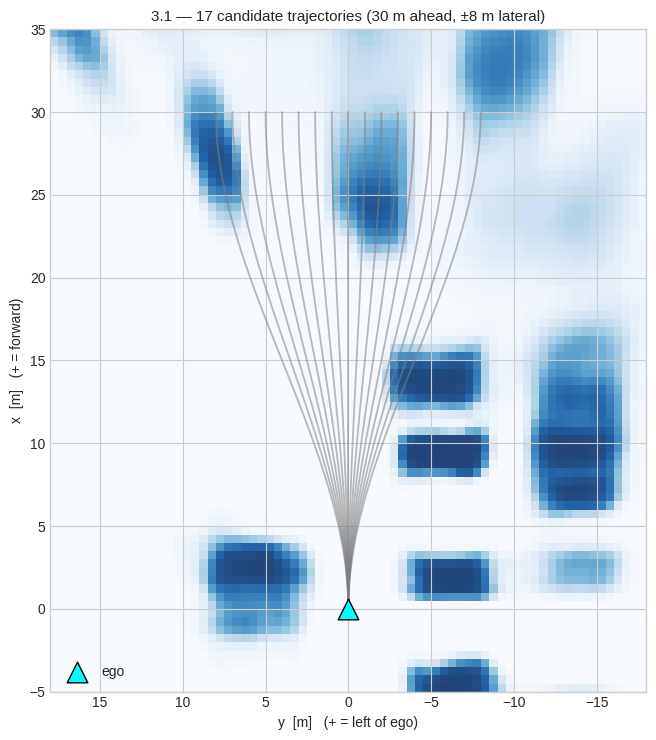

In [8]:
from matplotlib.gridspec import GridSpec

# --- BEV display helper (forward up, ego-left on the left) ------------------
BEV_EXTENT = [-50, 50, -50, 50]
def bev_show(ax, arr, **kw):
    kw.setdefault('extent', BEV_EXTENT)
    im = ax.imshow(arr, origin='lower', **kw)
    ax.invert_xaxis()
    ax.set_xlabel('y  [m]   (+ = left of ego)')
    ax.set_ylabel('x  [m]   (+ = forward)')
    ax.set_aspect('equal')
    return im

def smooth_traj(x_end, y_end, length_pts=40):
    """Cubic-hermite-smoothed path from (0, 0) with zero initial heading to (x_end, y_end)."""
    t = np.linspace(0, 1, length_pts)
    x = x_end * t
    y = y_end * (3 * t**2 - 2 * t**3)
    return np.stack([x, y], axis=1)

# 17 hand-crafted lane-change candidates, ±8 m lateral at 30 m forward.
# (Stand-in for the paper's 1000 k-means templates, not released with these weights.)
LATERAL_TARGETS = np.linspace(-8.0, 8.0, 17)
FORWARD_TARGET  = 30.0
trajectories    = [smooth_traj(FORWARD_TARGET, lat) for lat in LATERAL_TARGETS]

fig, ax = plt.subplots(figsize=(7.5, 7.5))
bev_show(ax, bev, cmap=BEV_CMAP, vmin=0, vmax=1, alpha=0.9)
for tr in trajectories:
    ax.plot(tr[:, 1], tr[:, 0], color='gray', alpha=0.55, lw=1.3)
ax.scatter([0], [0], c=PAL['cyan'], marker='^', s=220, edgecolor='black', zorder=5, label='ego')
ax.set_title(f'3.1 — {len(trajectories)} candidate trajectories ({FORWARD_TARGET:.0f} m ahead, ±{LATERAL_TARGETS.max():.0f} m lateral)',
             fontsize=11)
ax.set_xlim(18, -18); ax.set_ylim(-5, 35)
ax.legend(loc='lower left'); plt.tight_layout(); plt.show()


### 3.2 — Score each candidate on the vehicle BEV (approximated cost map)

For every candidate τ we look up the per-cell $P(\text{vehicle})$ along the path and sum the per-cell cost

$$c(\tau) = -\frac{1}{|\tau|} \sum_{(x, y)\in\tau} \log\big(1 - P(\text{vehicle at }(x, y))\big).$$

- A completely clear path  →  $P(\text{vehicle}) \approx 0$  →  $c(\tau) \approx 0$.
- A path that runs through a car  →  $P(\text{vehicle}) \to 1$  →  $c(\tau) \to +\infty$.

This is the same functional form the paper uses in its softmax over trajectories; only the source of the cost map differs (paper: learned planning head; us: released vehicle-segmentation head).


Best candidate: lateral target = +5.0 m   NLL = 0.002


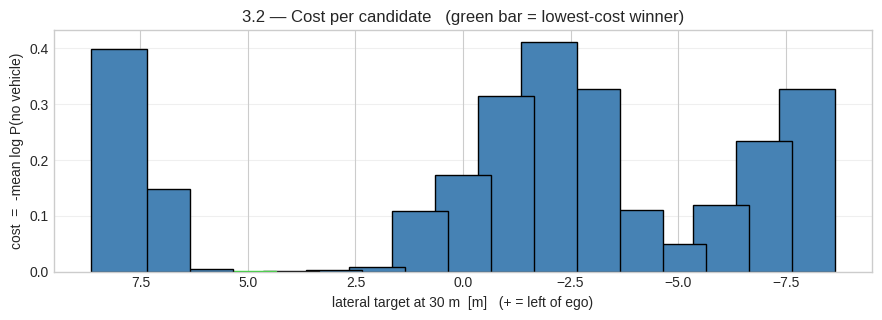

In [9]:
# --- paper-accurate cost ----------------------------------------------------
# LSS §5.1 uses  c(τ) = -Σ log P(no-vehicle at cell)  over the trajectory cells.
# The pretrained head outputs P(VEHICLE), so we need  1 - P(vehicle)  inside the log.
# The template bank in the paper is 1000 trajectories mined by k-means from the
# nuScenes training set — not released with the pretrained weights — so we
# substitute with our small hand-crafted bank from 3.1.

def trajectory_cost(traj, bev, grid_conf):
    xmin, _, xres = grid_conf['xbound']
    ymin, _, yres = grid_conf['ybound']
    xi = np.floor((traj[:, 0] - xmin) / xres).astype(int)
    yi = np.floor((traj[:, 1] - ymin) / yres).astype(int)
    if ((xi < 0) | (xi >= bev.shape[0]) | (yi < 0) | (yi >= bev.shape[1])).any():
        return float('inf')
    p = bev[xi, yi]                                    # P(vehicle) per cell
    return float(-np.mean(np.log(1.0 - p + 1e-3)))     # penalise cells likely occupied

costs    = np.array([trajectory_cost(tr, bev, grid_conf) for tr in trajectories])
best_idx = int(np.argmin(costs))
print(f'Best candidate: lateral target = {LATERAL_TARGETS[best_idx]:+.1f} m   NLL = {costs[best_idx]:.3f}')

fig, ax = plt.subplots(figsize=(9, 3.3))
bars = ax.bar(LATERAL_TARGETS, costs, width=1.3, color=PAL['blue'], edgecolor='black')
bars[best_idx].set_color('limegreen')
ax.set_xlabel('lateral target at 30 m  [m]   (+ = left of ego)')
ax.set_ylabel('cost  =  -mean log P(no vehicle)')
ax.set_title(f'3.2 — Cost per candidate   (green bar = lowest-cost winner)')
ax.invert_xaxis()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


### 3.3 — The winning trajectory

We color-code all candidates by their cost (green = low, red = high), highlight the winner in lime, and — as a sanity check — project it back onto the **CAM_FRONT** image so you can visually verify it lands on actual road.

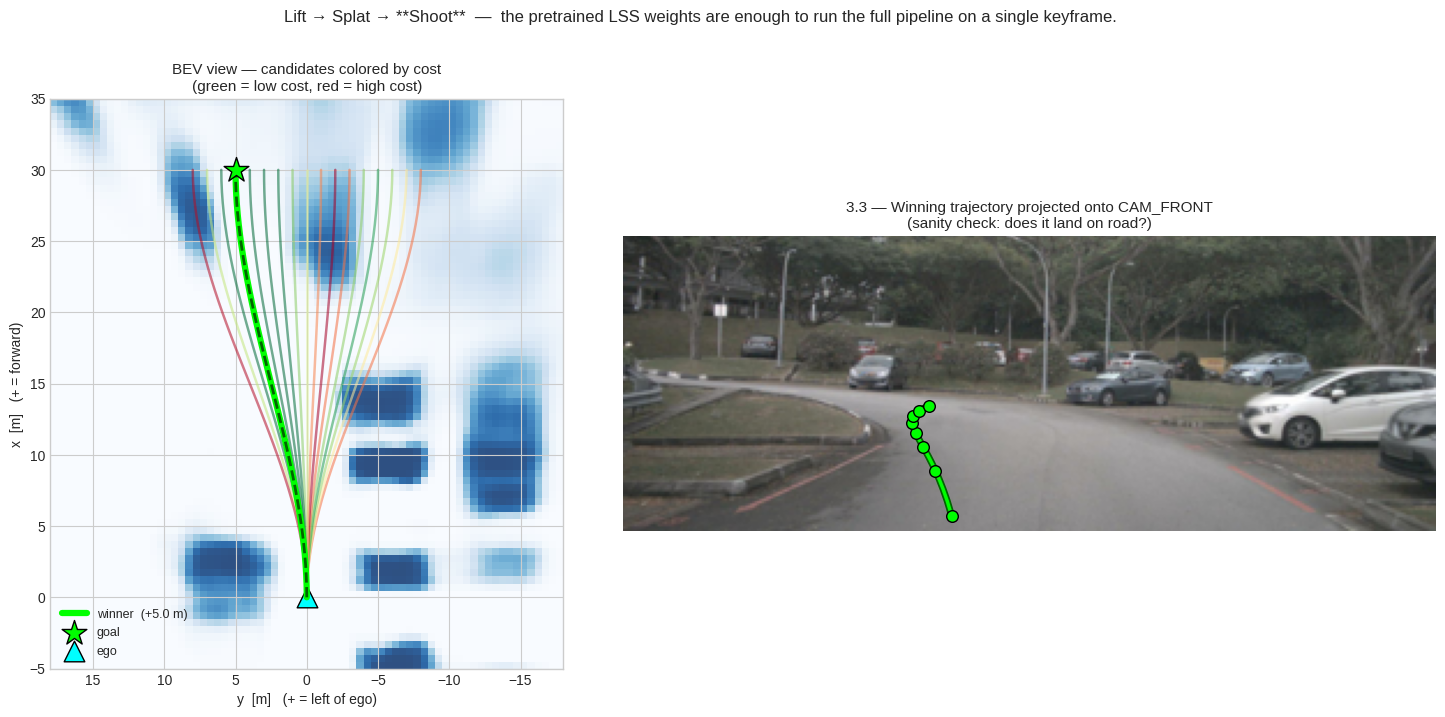

In [10]:
# Project a trajectory (z = 0) into the CAM_FRONT image plane using
# the same intrinsics / extrinsics / post-aug transforms that LSS used.
def project_to_cam(ego_xy, cam_idx, batch, imH, imW):
    R  = batch[1][0, cam_idx].cpu().numpy()       # cam_to_ego rotation
    t  = batch[2][0, cam_idx].cpu().numpy()       # cam_to_ego translation
    K  = batch[3][0, cam_idx].cpu().numpy()       # camera intrinsics
    pr = batch[4][0, cam_idx].cpu().numpy()       # post-aug rotation (3x3)
    pt = batch[5][0, cam_idx].cpu().numpy()       # post-aug translation (3,)

    pts_ego = np.column_stack([ego_xy[:, 0], ego_xy[:, 1], np.zeros(len(ego_xy))])
    pts_cam = (pts_ego - t) @ R                   # ego -> cam  (R orthonormal, so R^-1 = R^T)
    keep = pts_cam[:, 2] > 0.1
    pts_cam = pts_cam[keep]
    if len(pts_cam) < 2:
        return np.array([]), np.array([])
    uv = pts_cam @ K.T
    u0, v0 = uv[:, 0] / uv[:, 2], uv[:, 1] / uv[:, 2]
    u = pr[0, 0] * u0 + pr[0, 1] * v0 + pt[0]
    v = pr[1, 0] * u0 + pr[1, 1] * v0 + pt[1]
    ok = (u >= 0) & (u < imW) & (v >= 0) & (v < imH)
    return u[ok], v[ok]

# --- side-by-side: BEV view (left) + CAM_FRONT projection (right) --------
norm_costs = (costs - costs.min()) / (costs.max() - costs.min() + 1e-8)
cmap_rgb   = plt.get_cmap('RdYlGn_r')

fig = plt.figure(figsize=(15, 6.8))
gs  = GridSpec(1, 2, width_ratios=[1, 1.35])

ax_bev = fig.add_subplot(gs[0])
bev_show(ax_bev, bev, cmap=BEV_CMAP, alpha=0.85, vmin=0, vmax=1)
for i, tr in enumerate(trajectories):
    if i == best_idx: continue
    ax_bev.plot(tr[:, 1], tr[:, 0], color=cmap_rgb(norm_costs[i]), alpha=0.55, lw=1.8)
winner = trajectories[best_idx]
ax_bev.plot(winner[:, 1], winner[:, 0], color=PAL['green'],      lw=4.5, zorder=6, label=f'winner  ({LATERAL_TARGETS[best_idx]:+.1f} m)')
ax_bev.plot(winner[:, 1], winner[:, 0], color='darkgreen', lw=2.0, ls='--', zorder=7)
ax_bev.scatter([winner[-1, 1]], [winner[-1, 0]], c='lime', marker='*', s=350,
               edgecolor='black', zorder=8, label='goal')
ax_bev.scatter([0], [0], c=PAL['cyan'], marker='^', s=220, edgecolor='black', zorder=5, label='ego')
ax_bev.set_title('BEV view — candidates colored by cost\n(green = low cost, red = high cost)',
                 fontsize=11)
ax_bev.set_xlim(18, -18); ax_bev.set_ylim(-5, 35)
ax_bev.legend(loc='lower left', fontsize=9)

ax_cam = fig.add_subplot(gs[1])
ax_cam.imshow(pil_images[CAMS.index('CAM_FRONT')])
u, v = project_to_cam(winner, CAMS.index('CAM_FRONT'), batch, imH, imW)
if len(u) >= 2:
    ax_cam.plot(u, v, '-', color='darkgreen', lw=5)
    ax_cam.plot(u, v, '-', color=PAL['green'],      lw=2.5)
    ax_cam.scatter(u[::4], v[::4], c='lime', s=70, edgecolor='black', zorder=5)
ax_cam.set_title('3.3 — Winning trajectory projected onto CAM_FRONT\n(sanity check: does it land on road?)',
                 fontsize=11)
ax_cam.axis('off')

fig.suptitle('Lift → Splat → **Shoot**  —  the pretrained LSS weights are enough to run the full pipeline on a single keyframe.',
             fontsize=12, y=1.03)
plt.tight_layout(); plt.show()


## Part 4 — Camera + LiDAR Fusion in BEV

This is the core idea behind **BEVFusion** (Liu et al., 2022): once each modality produces features on the same BEV grid, fusion is literally `torch.cat` on the channel dimension.

```
Camera images  →  LSS (lift + splat)     →  Camera BEV   (64 channels, 200×200)
LiDAR points   →  rasterize into pillars  →  LiDAR BEV    (3 channels, 200×200)
                                                                          │
                                              Fused BEV = concat  ←────┘  (67 channels, 200×200)
                                                   │
                                              conv head → 3D boxes / segmentation
```

In a real BEVFusion, both branches have learned backbones (Swin-T for camera, VoxelNet for LiDAR).
Here we use the pretrained LSS for camera and a simple rasterization for LiDAR — the fusion *mechanism* is identical.

In [11]:
# Load the LiDAR point cloud for the same keyframe we've been using
from nuscenes.utils.data_classes import LidarPointCloud
from pyquaternion import Quaternion
import os

rec       = ds.ixes[SAMPLE_IDX]
lidar_sd  = nusc.get('sample_data', rec['data']['LIDAR_TOP'])
calib     = nusc.get('calibrated_sensor', lidar_sd['calibrated_sensor_token'])

pc = LidarPointCloud.from_file(os.path.join(nusc.dataroot, lidar_sd['filename']))
pc.rotate(Quaternion(calib['rotation']).rotation_matrix)
pc.translate(np.array(calib['translation']))

lidar_points     = pc.points[:3].T   # (N, 3) in ego frame
lidar_intensity  = pc.points[3]      # (N,)

print(f'LiDAR: {lidar_points.shape[0]:,} points in ego frame')
print(f'  x: {lidar_points[:,0].min():.1f} .. {lidar_points[:,0].max():.1f} m')
print(f'  y: {lidar_points[:,1].min():.1f} .. {lidar_points[:,1].max():.1f} m')
print(f'  z: {lidar_points[:,2].min():.1f} .. {lidar_points[:,2].max():.1f} m')

LiDAR: 34,720 points in ego frame
  x: -84.2 .. 93.4 m
  y: -71.0 .. 84.5 m
  z: -11.5 .. 16.5 m


In [12]:
# Rasterize LiDAR into a 3-channel BEV "image" on the same 200x200 grid as LSS.
# Channel 0: point density (how many returns per cell)
# Channel 1: max height   (tallest point in the cell)
# Channel 2: mean reflectance

xmin, xmax, xres = grid_conf['xbound']
ymin, ymax, yres = grid_conf['ybound']
X = int((xmax - xmin) / xres)   # 200
Y = int((ymax - ymin) / yres)   # 200

# Filter to points inside the BEV grid
mask = ((lidar_points[:, 0] >= xmin) & (lidar_points[:, 0] < xmax) &
        (lidar_points[:, 1] >= ymin) & (lidar_points[:, 1] < ymax))
pts = lidar_points[mask]
inten = lidar_intensity[mask]

xi = ((pts[:, 0] - xmin) / xres).astype(int)
yi = ((pts[:, 1] - ymin) / yres).astype(int)

density     = np.zeros((X, Y), dtype=np.float32)
max_height  = np.full((X, Y), -10.0, dtype=np.float32)
mean_refl   = np.zeros((X, Y), dtype=np.float32)

np.add.at(density, (xi, yi), 1)
np.maximum.at(max_height, (xi, yi), pts[:, 2])
np.add.at(mean_refl, (xi, yi), inten)
mean_refl = np.where(density > 0, mean_refl / density, 0)

# Normalize each channel to [0, 1]
density_norm    = np.log1p(density) / np.log1p(density).max()
height_norm     = (max_height - max_height[max_height > -10].min()) / (max_height.max() - max_height[max_height > -10].min() + 1e-6)
height_norm     = np.clip(height_norm, 0, 1)
refl_norm       = mean_refl / (mean_refl.max() + 1e-6)

lidar_bev = np.stack([density_norm, height_norm, refl_norm])  # (3, 200, 200)

print(f'LiDAR BEV shape: {lidar_bev.shape}')
print(f'  channel 0 (density):     {density_norm.min():.2f} .. {density_norm.max():.2f}')
print(f'  channel 1 (max height):  {height_norm.min():.2f} .. {height_norm.max():.2f}')
print(f'  channel 2 (reflectance): {refl_norm.min():.2f} .. {refl_norm.max():.2f}')
print(f'  cells with ≥1 point: {(density > 0).sum():,} / {X*Y:,}')

LiDAR BEV shape: (3, 200, 200)
  channel 0 (density):     0.00 .. 1.00
  channel 1 (max height):  0.00 .. 1.00
  channel 2 (reflectance): 0.00 .. 1.00
  cells with ≥1 point: 4,533 / 40,000


/tmp/ipykernel_1868/3809978534.py:27: RuntimeWarning: invalid value encountered in divide
  mean_refl = np.where(density > 0, mean_refl / density, 0)


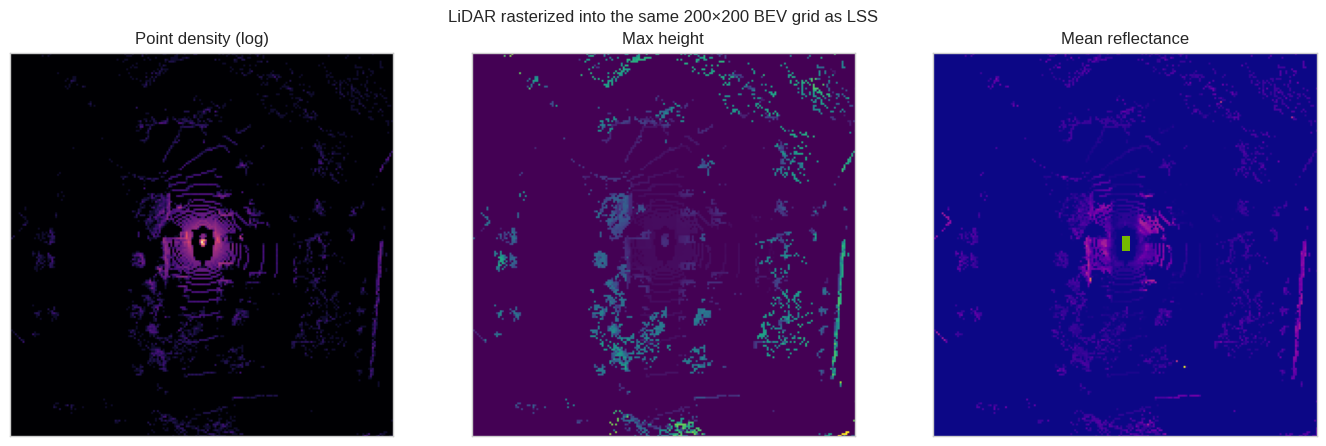

In [13]:
# Show the 3 LiDAR BEV channels
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
titles = ['Point density (log)', 'Max height', 'Mean reflectance']
cmaps  = ['magma', 'viridis', 'plasma']

for ax, ch, title, cmap in zip(axes, lidar_bev, titles, cmaps):
    ax.imshow(ch, cmap=cmap)
    add_ego(grid_origin, cell_size)
    ax.set_xlim(ch.shape[1], 0); ax.set_ylim(0, ch.shape[0])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)

plt.suptitle('LiDAR rasterized into the same 200×200 BEV grid as LSS', fontsize=12)
plt.tight_layout(); plt.show()

In [14]:
# === THE FUSION ===
# Camera BEV: 64 channels from LSS's voxel_pooling (computed in Part 2)
# LiDAR BEV:  3 channels from rasterization (computed above)
# Fused BEV:  just concat them.

camera_bev = bev_feat[0].cpu()   # (64, 200, 200) from Part 2's splat
lidar_bev_tensor = torch.from_numpy(lidar_bev).float()  # (3, 200, 200)
fused_bev = torch.cat([camera_bev, lidar_bev_tensor], dim=0)  # (67, 200, 200)

print('=== Fusion ===')
print(f'  Camera BEV:  {tuple(camera_bev.shape)}   (from LSS lift+splat)')
print(f'  LiDAR BEV:   {tuple(lidar_bev_tensor.shape)}   (from rasterization)')
print(f'  Fused BEV:   {tuple(fused_bev.shape)}   (= torch.cat on channel dim)')
print()
print('In a real BEVFusion, both branches have learned backbones.')
print('The LiDAR branch would use VoxelNet or PointPillars instead of raw rasterization.')
print('But the fusion step is always the same: just concatenate the BEV features.')

=== Fusion ===
  Camera BEV:  (64, 200, 200)   (from LSS lift+splat)
  LiDAR BEV:   (3, 200, 200)   (from rasterization)
  Fused BEV:   (67, 200, 200)   (= torch.cat on channel dim)

In a real BEVFusion, both branches have learned backbones.
The LiDAR branch would use VoxelNet or PointPillars instead of raw rasterization.
But the fusion step is always the same: just concatenate the BEV features.


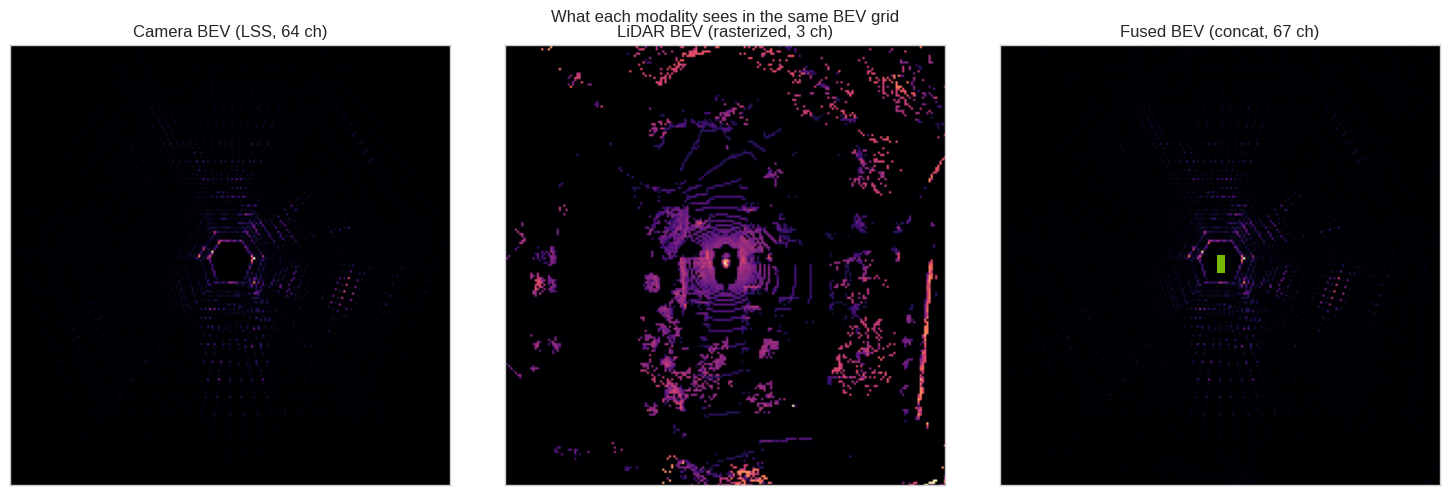


Camera activates on appearance cues (lane markings, vehicle textures, facades).
LiDAR activates on every physical surface (exact geometry, no appearance).
Fused = both signals in one tensor. A downstream conv head gets the best of both.


In [15]:
# Compare: camera-only vs LiDAR-only vs fused
# Show the feature magnitude for each (where does each modality place features?)
camera_mag = camera_bev.norm(dim=0).numpy()
lidar_mag  = np.linalg.norm(lidar_bev, axis=0)
fused_mag  = fused_bev.norm(dim=0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
data   = [camera_mag, lidar_mag, fused_mag]
titles = ['Camera BEV (LSS, 64 ch)',
          'LiDAR BEV (rasterized, 3 ch)',
          'Fused BEV (concat, 67 ch)']

for ax, d, title in zip(axes, data, titles):
    ax.imshow(d, cmap='magma')
    add_ego(grid_origin, cell_size)
    ax.set_xlim(d.shape[1], 0); ax.set_ylim(0, d.shape[0])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)

plt.suptitle('What each modality sees in the same BEV grid', fontsize=12)
plt.tight_layout(); plt.show()

print()
print('Camera activates on appearance cues (lane markings, vehicle textures, facades).')
print('LiDAR activates on every physical surface (exact geometry, no appearance).')
print('Fused = both signals in one tensor. A downstream conv head gets the best of both.')

## Part 5 — Full-scene replay (video)

nuScenes mini has 2 Hz keyframes, ~40 per scene. We run LSS on every keyframe of one scene and animate the output — CAM_FRONT on the left, predicted-vehicle BEV + map on the right.

In [16]:
from tqdm import tqdm

# Pick the first scene in mini_val; list its keyframe indices into ds.ixes
# Pick the first scene that ds actually contains (mini_val has 2 scenes)
scene_token = ds.ixes[0]["scene_token"]
scene       = nusc.get("scene", scene_token)
scene_idx   = [i for i, r in enumerate(ds.ixes) if r['scene_token'] == scene_token]
print(f'{len(scene_idx)} keyframes in scene {scene["name"]!r}')

# Run LSS on every keyframe; cache BEV + denormed CAM_FRONT for the animation
bevs, fronts = [], []
front_i = CAMS.index('CAM_FRONT')
for i in tqdm(scene_idx):
    imgs, rots, trans, intrins, post_rots, post_trans, _ = ds[i]
    b = [x[None].to(device) for x in (imgs, rots, trans, intrins, post_rots, post_trans)]
    with torch.no_grad():
        bevs.append(model(*b).sigmoid()[0, 0].cpu().numpy())
    fronts.append(denormalize_img(imgs[front_i]))


41 keyframes in scene 'scene-0916'


100%|██████████| 41/41 [00:09<00:00,  4.41it/s]


In [17]:
import io, imageio
from IPython.display import Video


# Render each frame as a fresh figure (so map polygons don't pile up)
frames = []
for i in range(len(bevs)):
    fig, (ax_cam, ax_bev) = plt.subplots(1, 2, figsize=(10, 4), dpi=100)

    ax_cam.imshow(fronts[i]); ax_cam.axis('off')
    ax_cam.set_title(f'CAM_FRONT — frame {i+1}/{len(bevs)}')

    ax_bev.imshow(bevs[i], vmin=0, vmax=1, cmap=BEV_CMAP)
    plot_nusc_map(ds.ixes[scene_idx[i]], nusc_maps, nusc, scene2map, cell_size, grid_origin)
    add_ego(grid_origin, cell_size)
    ax_bev.set_xlim(bevs[i].shape[1], 0)
    ax_bev.set_ylim(0, bevs[i].shape[0])
    ax_bev.set_xticks([]); ax_bev.set_yticks([])
    ax_bev.set_title('LSS vehicle BEV + map')

    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100)
    buf.seek(0)
    frames.append(np.array(Image.open(buf))[:, :, :3])
    plt.close(fig)

imageio.mimsave('lss_video.mp4', frames, fps=4)
print(f'Saved {len(frames)} frames to lss_video.mp4')
Video('lss_video.mp4', embed=True, width=900)


Saved 41 frames to lss_video.mp4


### Video 1 — Depth distribution over time

For every keyframe in the scene: CAM_FRONT on the left, depth PDF at the center pixel on the right. Watch how the network's depth estimate shifts as the car moves.

In [ ]:
from sklearn.decomposition import PCA as _PCA
from PIL import Image as _PILImage

all_indices = list(range(len(ds.ixes)))

frames_v1 = []
for idx in tqdm(all_indices):
    imgs, rots, trans, intrins, post_rots, post_trans, _ = ds[idx]
    b = [x[None].to(device) for x in (imgs, rots, trans, intrins, post_rots, post_trans)]
    images_f = b[0].view(6, 3, imH, imW)

    with torch.no_grad():
        bb           = model.camencode.get_eff_depth(images_f)
        logits       = model.camencode.depthnet(bb)
        d_dist_frame = logits[:, :num_depth_bins].softmax(dim=1)
        feats_frame  = logits[:, num_depth_bins:]

    front_idx = CAMS.index('CAM_FRONT')

    # PCA: 64-d features -> RGB for CAM_FRONT
    C, H, W = feats_frame[front_idx].shape
    feat_np = feats_frame[front_idx].reshape(C, -1).T.cpu().numpy()
    pca     = _PCA(n_components=3).fit_transform(feat_np)
    pca     = (pca - pca.min(0)) / (pca.max(0) - pca.min(0) + 1e-6)
    rgb_2d  = pca.reshape(H, W, 3)
    rgb_up  = np.asarray(_PILImage.fromarray((rgb_2d * 255).astype(np.uint8))
                         .resize((imW, imH), _PILImage.BICUBIC)) / 255.0

    pdf      = d_dist_frame[front_idx, :, feat_h//2, feat_w//2].cpu().numpy()
    expected = float((pdf * depth_bins_np).sum())
    front_img = denormalize_img(imgs[front_idx])

    fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(16, 4), dpi=90)

    ax0.imshow(front_img); ax0.axis('off')
    ax0.set_title('CAM_FRONT')

    ax1.imshow(front_img)
    ax1.imshow(rgb_up, alpha=0.25)
    ax1.axis('off')
    ax1.set_title('2D features (PCA→RGB)')

    ax2.bar(depth_bins_np, pdf, width=0.9, color=PAL['blue'], alpha=0.9)
    ax2.fill_between(depth_bins_np, pdf, alpha=0.2, color=PAL['blue'])
    ax2.axvline(expected, color=PAL['green'], lw=2, linestyle='--', label=f'E[d] = {expected:.1f} m')
    ax2.set_xlim(3.5, 45.5); ax2.set_ylim(0, 0.35)
    ax2.set_xlabel('depth [m]'); ax2.set_ylabel('P(depth)')
    ax2.set_title('Depth PDF — center pixel')
    ax2.legend()

    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=90); buf.seek(0)
    frames_v1.append(np.array(Image.open(buf))[:, :, :3])
    plt.close(fig)

imageio.mimsave('video_depth.mp4', frames_v1, fps=8)
Video('video_depth.mp4', embed=True, width=900)

### Video 2 — Planning over time

For every keyframe: winning trajectory projected onto CAM_FRONT on the left, all 17 candidates scored on the vehicle BEV on the right. Green = lowest cost, red = highest.

In [ ]:
xmin, _, xres = grid_conf['xbound']
ymin, _, yres = grid_conf['ybound']

frames_v2 = []
for idx in tqdm(scene_idx):
    imgs, rots, trans, intrins, post_rots, post_trans, _ = ds[idx]
    b = [x[None].to(device) for x in (imgs, rots, trans, intrins, post_rots, post_trans)]

    with torch.no_grad():
        bev_frame = model(*b).sigmoid()[0, 0].cpu().numpy()

    costs      = np.array([trajectory_cost(tr, bev_frame, grid_conf) for tr in trajectories])
    best_idx   = int(np.argmin(costs))
    norm_costs = (costs - costs.min()) / (costs.max() - costs.min() + 1e-8)
    winner     = trajectories[best_idx]

    fig, ax = plt.subplots(figsize=(7, 7), dpi=90)
    ax.imshow(bev_frame, vmin=0, vmax=1, cmap=BEV_CMAP)
    plot_nusc_map(ds.ixes[idx], nusc_maps, nusc, scene2map, cell_size, grid_origin)

    cmap_costs = plt.get_cmap('RdYlGn_r')
    for j, tr in enumerate(trajectories):
        col = (tr[:, 1] - ymin) / yres
        row = (tr[:, 0] - xmin) / xres
        if j == best_idx: continue
        ax.plot(col, row, color=cmap_costs(norm_costs[j]), alpha=0.55, lw=1.5)

    w_col = (winner[:, 1] - ymin) / yres
    w_row = (winner[:, 0] - xmin) / xres
    ax.plot(w_col, w_row, color=PAL['green'], lw=4, zorder=6,
            label=f'winner ({LATERAL_TARGETS[best_idx]:+.1f} m)')

    add_ego(grid_origin, cell_size)
    ax.set_xlim(bev_frame.shape[1], 0)
    ax.set_ylim(0, bev_frame.shape[0])
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=9, loc='upper right')
    ax.set_title(f'Planning — winner at {LATERAL_TARGETS[best_idx]:+.1f} m lateral')

    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=90); buf.seek(0)
    frames_v2.append(np.array(Image.open(buf))[:, :, :3])
    plt.close(fig)

imageio.mimsave('video_planning.mp4', frames_v2, fps=4)
Video('video_planning.mp4', embed=True, width=700)

### Wrap-up

| Stage | What you saw | Source of truth |
|------|-------------|-----------------|
| **Lift**  | 2D features per camera, categorical depth PDF, outer-product frustum | `CamEncode` in `src/models.py` |
| **Splat** | 6 frustums → one `(C=64, 200, 200)` BEV tensor via cumsum pooling | `LiftSplatShoot.voxel_pooling` |
| **Shoot** (approximated) | 17 candidate trajectories scored on the vehicle BEV; lowest-cost winner | paper §3.3 in spirit only — the real Shoot uses a separate planning head + 1000 k-means templates, neither released |

**Honest caveats for the classroom:**

- The pretrained weights (`model525000.pt`) are the vehicle-segmentation head. No drivable-area, no planning, no LiDAR fusion.
- Every Shoot result here is therefore a proxy: the cost map only says "where other vehicles are", not "where the expert would drive". For a correct `p(τ|o)` you'd retrain LSS with a planning head — or switch to a planner checkpoint (UniAD, VAD, GenAD, …) in a follow-up lab.

**Follow-up labs in this DLC:**

- **Lab 2 — BEV Fusion / BEVFormer.** Add LiDAR (proper early fusion) or learned BEV queries with deformable cross-attention.
- **Lab 3 — SurroundOcc / VoxFormer.** Full 3-D occupancy prediction with height slices.
